# Quantum Machine Learning with a TwoLocal Variational Classifier -- Optimized Qiskit

This notebook is a **drop-in-equivalent, dramatically faster** version of
[`../Parallel_QML.ipynb`](../Parallel_QML.ipynb). Same datasets, same
ZZFeatureMap + TwoLocal model, same SPSA optimizer, same Method 1 / Method 2
split, same results -- it just trains in seconds instead of an estimated hour
(Method 1) or an infeasible amount of time (Method 2).

## Why the original is slow, and what changed

Three compounding issues in the original notebook's `qc1()`/`qc2()`/`make_backend()`:

1. **Everything is rebuilt from scratch on every cost evaluation** -- a brand
   new `QuantumCircuit` (`ZZFeatureMap`, `TwoLocal`, `.assign_parameters()`,
   `.to_gate()`) for every one of the 128 training points, then `transpile()`
   on the whole batch, every single time -- even though only the variational
   *values* change between SPSA iterations, not the circuit's structure.
2. **Method 2's "Enc" block is rebuilt every call too**, even though it only
   depends on the fixed training data, never on the parameters being optimized.
3. **The real killer:** `fm_gate.control(num_ctrl_qubits=n1)` asks Qiskit to
   synthesize a generic 7-controlled arbitrary unitary with no ancilla
   qubits -- this blows up combinatorially (measured: 588 gates at 2
   controls, 5,004 at 3, 14,348 at 4; the real case has 7).

[`qc_core.py`](qc_core.py) fixes all three: it uses Qiskit's own
`ZZFeatureMap`/`TwoLocal` + `quantum_info.Operator` to derive the small (4x4)
unitary matrices -- guaranteeing exact correctness -- **caches** the
per-data-point encoder matrices (they never change across SPSA iterations),
and applies everything via batched NumPy instead of `transpile()` +
`AerSimulator`. See [`README.md`](README.md) and [`benchmark.py`](benchmark.py)
for the full writeup and measured numbers (**274x** faster per Method-1
evaluation; a full 200-iteration training run drops from an estimated >1 hour
to ~12 seconds).

## How to use this notebook
1. Edit the **Configuration** cell below.
2. *Run All*. Training that was previously impractical now finishes in seconds.

## 1. Configuration  *(the only cell you normally edit)*

In [29]:
# ============================ USER SETTINGS ============================
# Pick the dataset family:  "checkerboard" | "circles" | "corners" | "semicircles"
DATASET_TYPE = "checkerboard"

# Pick the instance:  an integer from 1 to 10
DATASET_NUM = 5

# What to do:
#   "load"  -> read the pre-computed results shipped in ../results (fast, no training)
#   "train" -> train the model live with SPSA -- now fast enough to actually run here
MODE = "train"

# Which circuit construction(s) to run / display:
#   [1]    -> only Method 1 (one circuit per sample)
#   [2]    -> only Method 2 (all samples in superposition)
#   [1, 2] -> both, shown side by side
METHODS = [1, 2]

# --- settings used only when MODE == "train" ---
MAXITER = 500          # SPSA iterations (same default as the original notebook)
SEED    = 42            # random seed for the initial parameters (reproducibility)

# --- visualization ---
PLOT_DECISION_BOUNDARY = False   # draw the learned decision boundary (a bit slower)
GRID_RES = 60                    # resolution of the decision-boundary grid
# ======================================================================

assert DATASET_TYPE in {"checkerboard", "circles", "corners", "semicircles"}
assert 1 <= DATASET_NUM <= 10
assert MODE in {"load", "train"}
assert all(m in (1, 2) for m in METHODS) and len(METHODS) >= 1
print(f"Dataset : {DATASET_TYPE} / dataset{DATASET_NUM}")
print(f"Mode    : {MODE}   |   Method(s): {METHODS}")

Dataset : checkerboard / dataset5
Mode    : train   |   Method(s): [1, 2]


## 2. Imports

In [30]:
import os
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit.circuit.library import ZZFeatureMap, TwoLocal

import sys
sys.path.insert(0, os.path.abspath("."))
from qc_core import Method1Classifier, Method2Classifier, two_local_num_params

warnings.filterwarnings("ignore")
np.random.seed(SEED)

## 3. Load the selected dataset

Train data : (128, 2),  labels: (128,)
Test  data : (64, 2),  labels: (64,)


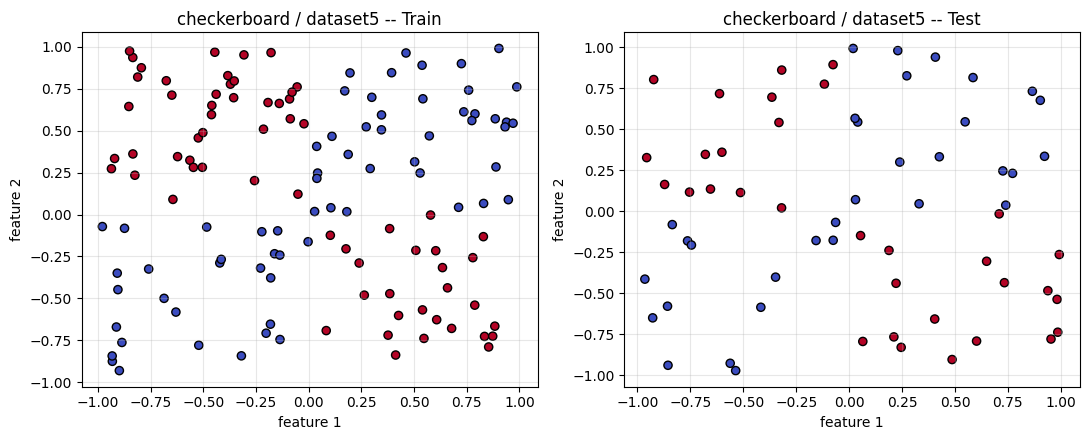

In [31]:
DATA_DIR    = os.path.join("..", "datasets", DATASET_TYPE, f"dataset{DATASET_NUM}")
RESULTS_DIR = os.path.join("..", "results",  DATASET_TYPE, f"dataset{DATASET_NUM}")

train_data   = pd.read_csv(os.path.join(DATA_DIR, "train_data")).to_numpy()
train_labels = pd.read_csv(os.path.join(DATA_DIR, "train_labels")).to_numpy().flatten()
test_data    = pd.read_csv(os.path.join(DATA_DIR, "test_data")).to_numpy()
test_labels  = pd.read_csv(os.path.join(DATA_DIR, "test_labels")).to_numpy().flatten()

print(f"Train data : {train_data.shape},  labels: {train_labels.shape}")
print(f"Test  data : {test_data.shape},  labels: {test_labels.shape}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, X, y, name in [(axes[0], train_data, train_labels, "Train"),
                       (axes[1], test_data,  test_labels,  "Test")]:
    sc = ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k", s=35)
    ax.set_title(f"{DATASET_TYPE} / dataset{DATASET_NUM} -- {name}")
    ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Quantum-circuit hyperparameters

In [37]:
num_reupload = 4
num_features = train_data.shape[1]

clf1 = Method1Classifier(n_features=num_features, num_reupload=num_reupload)
clf2 = Method2Classifier(n_features=num_features, num_reupload=num_reupload,
                          num_data=len(train_data)) if 2 in METHODS else None

num_parameters = clf1.num_parameters
num_register = clf2.n_index if clf2 is not None else int(np.log2(len(train_data)))

print(f"Re-uploads        : {num_reupload}")
print(f"Feature qubits    : {num_features}")
print(f"Index register    : {num_register} qubits  (Method 2)")
print(f"Trainable params  : {num_parameters}")

Re-uploads        : 4
Feature qubits    : 2
Index register    : 7 qubits  (Method 2)
Trainable params  : 32


## 5. Circuit definitions

Both methods use exactly the same circuit *structure* as the original
notebook -- a **ZZFeatureMap** encoder re-uploaded through a **TwoLocal**
(`ry`, `rz`, `cz`, full entanglement) ansatz, 4 times. The reference building
blocks are drawn below for context (unchanged from the original notebook);
the speedup comes entirely from how `qc_core.py` *evaluates* these circuits
across the dataset (cached matrices + batched NumPy), not from a different
circuit.

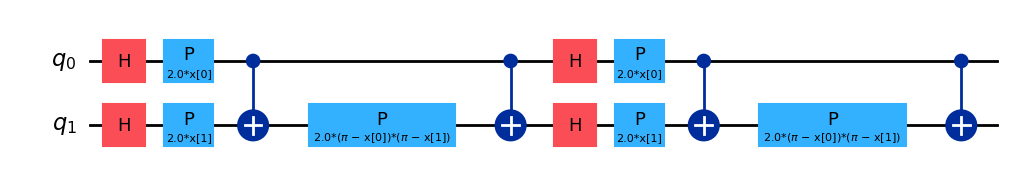

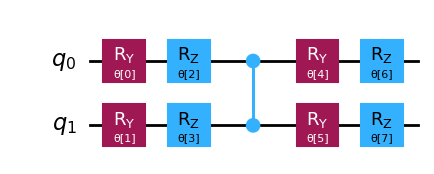

In [38]:
display(ZZFeatureMap(feature_dimension=num_features).decompose().draw('mpl'))
display(TwoLocal(num_features, ['ry', 'rz'], 'cz', 'full', reps=1).decompose().draw('mpl'))

## 6. Training / evaluation functions

Accuracy is always measured with the Method-1 per-sample read-out, so trained
parameters from either method are evaluated consistently -- exactly as in the
original notebook.

In [39]:
def performance_evaluation(data, labels, variational):
    '''Return (accuracy, predictions) using the Method-1 read-out.'''
    return clf1.performance_evaluation(data, labels, variational)


def objective_function_1(variational):
    return clf1.cost(train_data, train_labels, variational)


def objective_function_2(variational):
    return clf2.cost(train_data, variational)


class OptimizerLog:
    '''Records SPSA progress and evaluates train/test accuracy each iteration.'''
    def __init__(self):
        self.evaluations, self.parameters, self.costs = [], [], []
        self.train_accuracies, self.test_accuracies, self.stepsizes = [], [], []

    def update(self, evaluation, parameter, cost, stepsize, accepted):
        self.evaluations.append(evaluation)
        self.parameters.append(parameter.copy())
        self.costs.append(cost)
        self.stepsizes.append(stepsize)
        tr, _ = performance_evaluation(train_data, train_labels, parameter)
        te, _ = performance_evaluation(test_data,  test_labels,  parameter)
        self.train_accuracies.append(tr)
        self.test_accuracies.append(te)
        print(f" Iter {len(self.evaluations):3d}: loss={cost:.4f}  "
              f"train_acc={tr:.4f}  test_acc={te:.4f}  step={stepsize:.4f}")

## 7. Run training **or** load the saved results

Same `qiskit_machine_learning.optimizers.SPSA` as the original notebook --
only the cost function underneath is fast now.

In [40]:
results = {}

for METHOD in METHODS:
    print(f"\n########## Method {METHOD} ##########")
    if MODE == "train":
        from qiskit_machine_learning.optimizers import SPSA
        print(f"Training Method {METHOD} with SPSA ({MAXITER} iterations)...\n")
        np.random.seed(SEED)
        initial_point = np.random.uniform(-np.pi, np.pi, size=num_parameters)
        log = OptimizerLog()
        objective = objective_function_1 if METHOD == 1 else objective_function_2
        optimizer = SPSA(maxiter=MAXITER, callback=log.update)

        t0 = time.time()
        result = optimizer.minimize(objective, initial_point)
        elapsed = time.time() - t0

        history = {
            "costs": log.costs,
            "train_accuracies": log.train_accuracies,
            "test_accuracies": log.test_accuracies,
            "stepsizes": log.stepsizes,
            "final_cost": float(result.fun),
        }
        final_params = result.x
        print(f"\nDone in {elapsed:.1f}s. Final cost = {result.fun:.6f}")

    else:  # MODE == "load"
        json_path = os.path.join(RESULTS_DIR, f"method{METHOD}.json")
        print(f"Loading saved results from: {json_path}")
        with open(json_path, encoding="utf-8") as f:
            saved = json.load(f)
        th = saved["training_history"]
        fr = saved["final_results"]
        history = {
            "costs": th["costs"],
            "train_accuracies": th["train_accuracies"],
            "test_accuracies": th["test_accuracies"],
            "stepsizes": th["stepsizes"],
            "final_cost": fr["final_cost"],
        }
        final_params = np.array(fr["final_parameters"])
        print(f"Loaded {len(history['costs'])} iterations  "
              f"(optimizer: {saved['experiment_info']['optimizer']})")

        # Correctness check: re-evaluate the saved parameters with the
        # optimized classifier and confirm the predictions agree exactly.
        opt_test_acc, opt_test_pred = performance_evaluation(test_data, test_labels, final_params)
        agreement = np.mean([int(a == b) for a, b in zip(opt_test_pred, fr["test_predictions"])])
        print(f"Optimized re-evaluation: test_acc={opt_test_acc:.4f} "
              f"(original reported {fr['final_test_accuracy']:.4f}), "
              f"prediction agreement = {agreement:.4f}")

    results[METHOD] = {"history": history, "final_params": final_params}


########## Method 1 ##########
Training Method 1 with SPSA (500 iterations)...

 Iter   1: loss=0.8099  train_acc=0.5234  test_acc=0.3750  step=6.1205
 Iter   2: loss=0.8112  train_acc=0.5156  test_acc=0.3750  step=0.0592
 Iter   3: loss=0.7530  train_acc=0.5859  test_acc=0.4688  step=1.0233
 Iter   4: loss=0.7098  train_acc=0.5938  test_acc=0.4844  step=2.5309
 Iter   5: loss=0.7110  train_acc=0.6172  test_acc=0.4844  step=0.0478
 Iter   6: loss=0.7055  train_acc=0.6016  test_acc=0.5781  step=0.3847
 Iter   7: loss=0.6915  train_acc=0.6172  test_acc=0.5312  step=0.6358
 Iter   8: loss=0.6959  train_acc=0.6016  test_acc=0.6094  step=1.1115
 Iter   9: loss=0.5779  train_acc=0.6797  test_acc=0.5781  step=1.9531
 Iter  10: loss=0.5783  train_acc=0.6562  test_acc=0.5781  step=0.0396
 Iter  11: loss=0.6009  train_acc=0.6641  test_acc=0.6562  step=1.0279
 Iter  12: loss=0.5808  train_acc=0.7109  test_acc=0.6250  step=1.4031
 Iter  13: loss=0.5913  train_acc=0.6797  test_acc=0.6562  step=0.5

## 8. Training curves

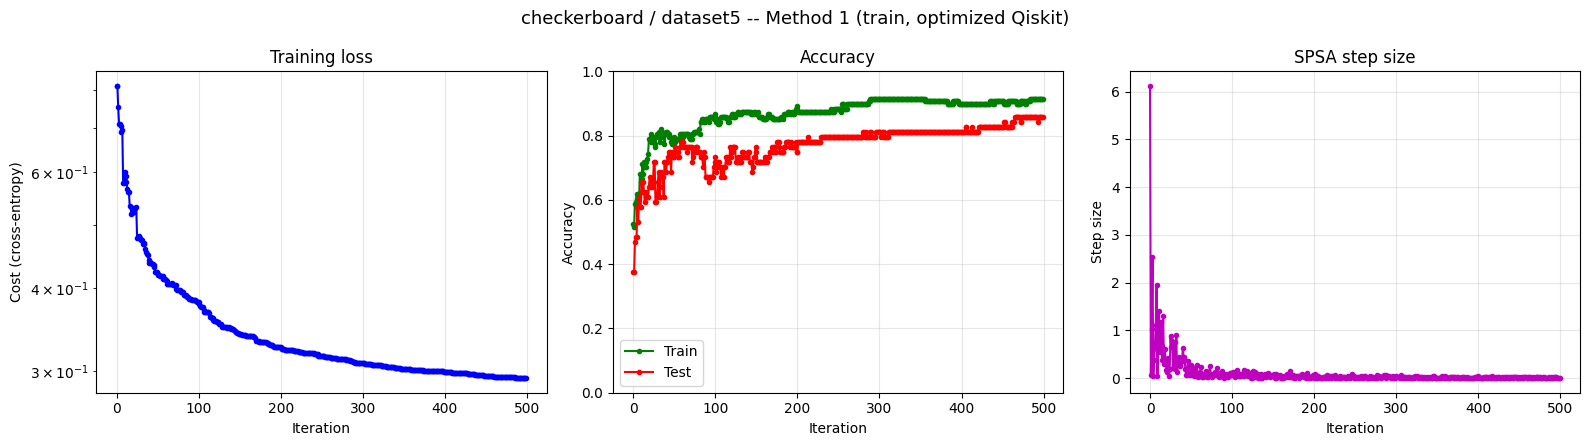

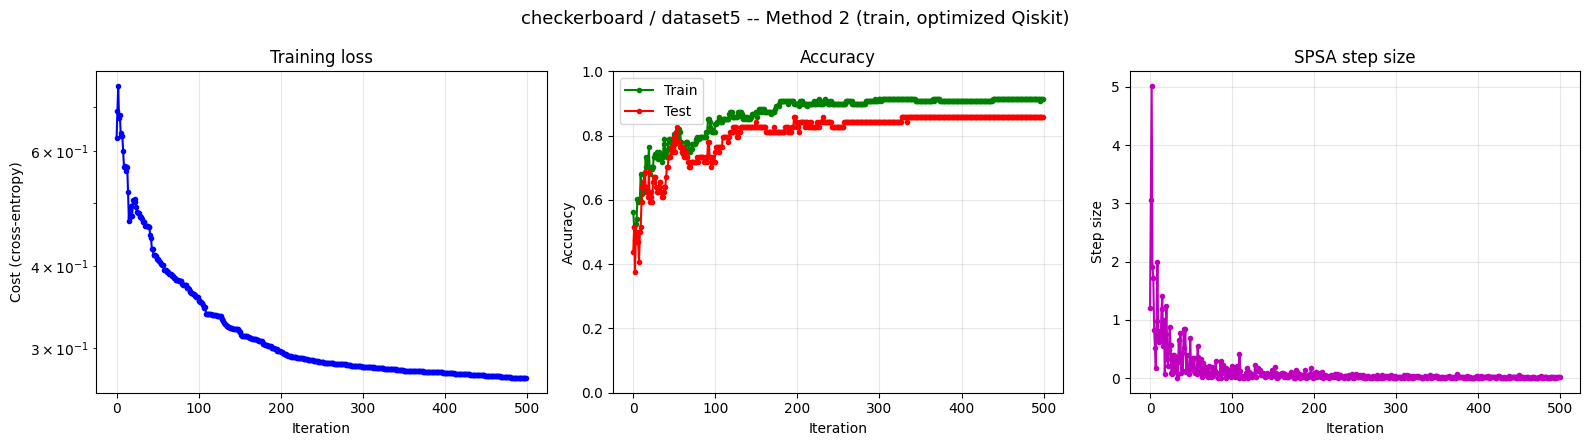

In [41]:
for METHOD in METHODS:
    history = results[METHOD]["history"]
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

    ax[0].plot(history["costs"], 'b-o', ms=3)
    ax[0].set_yscale('log'); ax[0].set_title("Training loss")
    ax[0].set_xlabel("Iteration"); ax[0].set_ylabel("Cost (cross-entropy)")
    ax[0].grid(alpha=0.3)

    ax[1].plot(history["train_accuracies"], 'g-o', ms=3, label="Train")
    ax[1].plot(history["test_accuracies"],  'r-o', ms=3, label="Test")
    ax[1].set_ylim(0, 1); ax[1].set_title("Accuracy")
    ax[1].set_xlabel("Iteration"); ax[1].set_ylabel("Accuracy")
    ax[1].legend(); ax[1].grid(alpha=0.3)

    ax[2].plot(history["stepsizes"], 'm-o', ms=3)
    ax[2].set_title("SPSA step size")
    ax[2].set_xlabel("Iteration"); ax[2].set_ylabel("Step size")
    ax[2].grid(alpha=0.3)

    fig.suptitle(f"{DATASET_TYPE} / dataset{DATASET_NUM} -- Method {METHOD} ({MODE}, optimized Qiskit)",
                 fontsize=13)
    plt.tight_layout(); plt.show()

## 9. Predictions and decision boundary

Predictions are computed with the trained parameters. The decision boundary is
evaluated on a grid using the Method-1 read-out (set `PLOT_DECISION_BOUNDARY=False`
in the config to skip the slower grid evaluation).

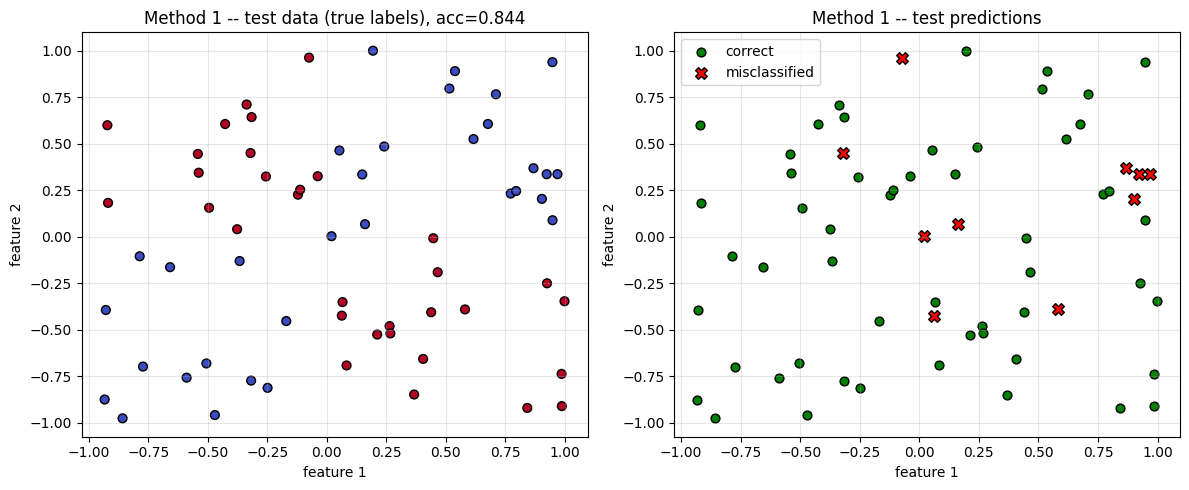

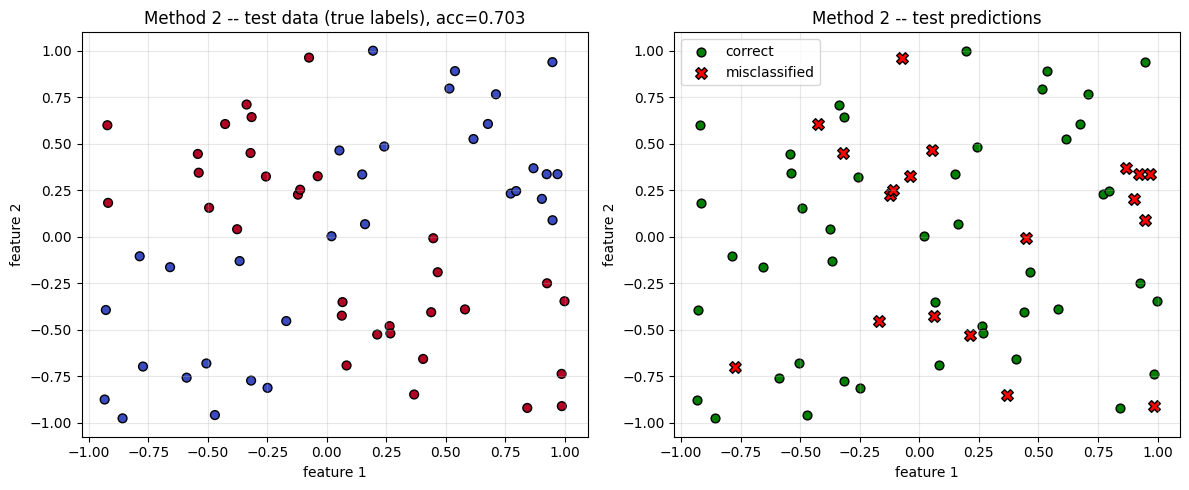

In [9]:
if PLOT_DECISION_BOUNDARY:
    allX = np.vstack([train_data, test_data])
    pad = 0.2
    x_min, x_max = allX[:, 0].min() - pad, allX[:, 0].max() + pad
    y_min, y_max = allX[:, 1].min() - pad, allX[:, 1].max() + pad
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, GRID_RES),
                         np.linspace(y_min, y_max, GRID_RES))
    grid = np.c_[xx.ravel(), yy.ravel()]

for METHOD in METHODS:
    final_params = results[METHOD]["final_params"]
    final_train_acc, train_pred = performance_evaluation(train_data, train_labels, final_params)
    final_test_acc,  test_pred  = performance_evaluation(test_data,  test_labels,  final_params)
    test_pred = np.array(test_pred)
    results[METHOD]["final_train_acc"] = final_train_acc
    results[METHOD]["final_test_acc"]  = final_test_acc

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    if PLOT_DECISION_BOUNDARY:
        print(f"Method {METHOD}: evaluating {GRID_RES}x{GRID_RES} decision-boundary grid...")
        probs = clf1.classification_probability(grid, final_params)
        zz = probs[:, 1].reshape(xx.shape)
        for ax in axes:
            ax.contourf(xx, yy, zz, levels=20, cmap="coolwarm", alpha=0.5)
            ax.contour(xx, yy, zz, levels=[0.5], colors="k", linewidths=1.5)

    ax = axes[0]
    ax.scatter(test_data[:, 0], test_data[:, 1], c=test_labels, cmap="coolwarm",
               edgecolors="k", s=40)
    ax.set_title(f"Method {METHOD} -- test data (true labels), acc={final_test_acc:.3f}")
    ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2"); ax.grid(alpha=0.3)

    ax = axes[1]
    correct = test_pred == test_labels
    ax.scatter(test_data[correct, 0], test_data[correct, 1], c="green",
               edgecolors="k", s=40, label="correct")
    ax.scatter(test_data[~correct, 0], test_data[~correct, 1], c="red",
               marker="X", edgecolors="k", s=70, label="misclassified")
    ax.set_title(f"Method {METHOD} -- test predictions")
    ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")
    ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout(); plt.show()

## 10. Final performance summary

In [10]:
print(f"Dataset: {DATASET_TYPE} / dataset{DATASET_NUM}    Mode: {MODE}    Implementation: optimized Qiskit\n")

rows = []
for METHOD in METHODS:
    h = results[METHOD]["history"]
    rows.append({
        "method": METHOD,
        "final_train_acc": round(results[METHOD]["final_train_acc"], 4),
        "final_test_acc":  round(results[METHOD]["final_test_acc"], 4),
        "best_test_acc":   round(max(h["test_accuracies"]), 4),
        "best_train_acc":  round(max(h["train_accuracies"]), 4),
        "final_cost":      round(h["final_cost"], 6),
    })

summary_methods = pd.DataFrame(rows).set_index("method")
display(summary_methods)

Dataset: checkerboard / dataset6    Mode: load    Implementation: optimized Qiskit



,final_train_acc,final_test_acc,best_test_acc,best_train_acc,final_cost
method,,,,,
1,0.9297,0.8438,0.8438,0.9375,0.363821
2,0.8594,0.7031,0.8281,0.8594,0.321153


## 11. (Optional) Compare all 10 instances of the selected family

A quick aggregate view across `dataset1` ... `dataset10` for the chosen
`DATASET_TYPE` and `METHOD`, read from the saved results shipped with the
original notebook. This does not depend on the single-dataset selection above.


===== checkerboard -- Method 1 (all 10 instances) =====


,final_test_acc,best_test_acc,final_train_acc,final_cost
dataset,,,,
1,0.8281,0.8438,0.8750,0.3823
2,0.7969,0.7969,0.8828,0.3448
3,0.7344,0.7812,0.7891,0.4231
4,0.7969,0.7969,0.8438,0.4027
5,0.6875,0.7188,0.8672,0.3892
6,0.8438,0.8438,0.9297,0.3638
7,0.7344,0.7344,0.8750,0.4203
8,0.7500,0.7969,0.8750,0.3662
9,0.7969,0.8438,0.8125,0.3999


Mean final test accuracy: 0.7750 +/- 0.0478


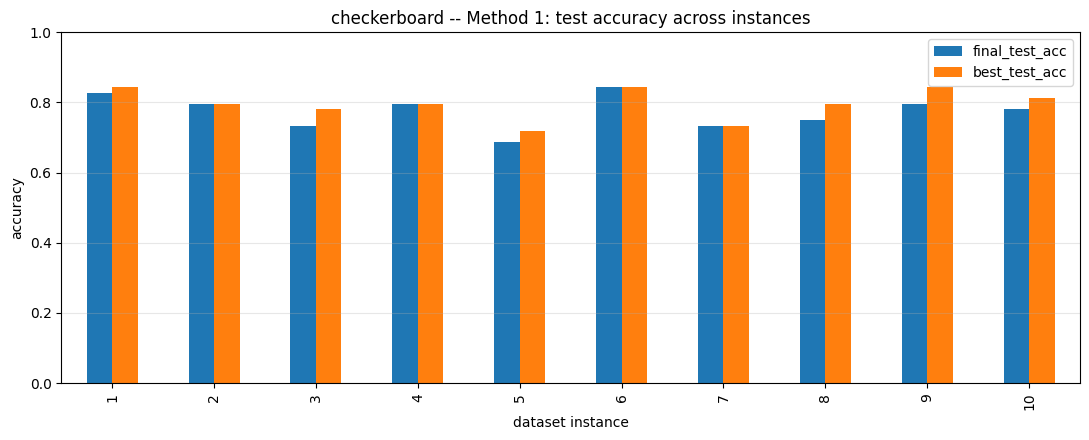


===== checkerboard -- Method 2 (all 10 instances) =====


,final_test_acc,best_test_acc,final_train_acc,final_cost
dataset,,,,
1,0.7031,0.7188,0.8203,0.3349
2,0.8281,0.8750,0.8203,0.3175
3,0.7188,0.7500,0.8438,0.3391
4,0.7656,0.8125,0.8828,0.3207
5,0.6875,0.7188,0.8828,0.3292
6,0.7031,0.8281,0.8594,0.3212
7,0.7500,0.7969,0.8516,0.3456
8,0.7969,0.7969,0.9141,0.2651
9,0.7656,0.7969,0.8906,0.3255


Mean final test accuracy: 0.7578 +/- 0.0572


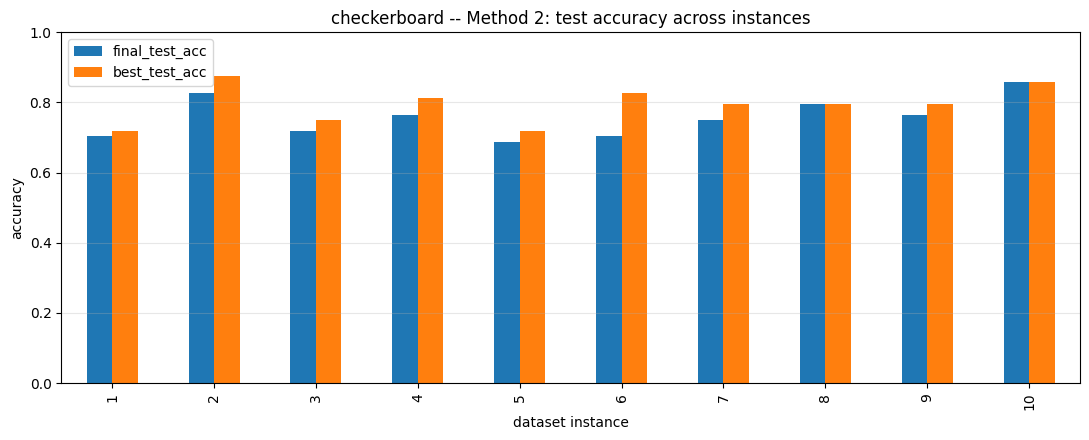

In [11]:
for METHOD in METHODS:
    rows = []
    for n in range(1, 11):
        p = os.path.join("..", "results", DATASET_TYPE, f"dataset{n}", f"method{METHOD}.json")
        if not os.path.exists(p):
            continue
        with open(p, encoding="utf-8") as f:
            s = json.load(f)
        fr, th = s["final_results"], s["training_history"]
        rows.append({
            "dataset": n,
            "final_test_acc": fr["final_test_accuracy"],
            "best_test_acc":  max(th["test_accuracies"]),
            "final_train_acc": fr["final_train_accuracy"],
            "final_cost": fr["final_cost"],
        })

    summary = pd.DataFrame(rows).set_index("dataset")
    print(f"\n===== {DATASET_TYPE} -- Method {METHOD} (all 10 instances) =====")
    display(summary.round(4))
    print(f"Mean final test accuracy: "
          f"{summary['final_test_acc'].mean():.4f} +/- {summary['final_test_acc'].std():.4f}")

    ax = summary[["final_test_acc", "best_test_acc"]].plot.bar(figsize=(11, 4.5))
    ax.set_title(f"{DATASET_TYPE} -- Method {METHOD}: test accuracy across instances")
    ax.set_xlabel("dataset instance"); ax.set_ylabel("accuracy"); ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

## 12. Speed comparison vs. the original implementation

A direct, reproducible benchmark against the original `qc1()`/`qc2()` +
`AerSimulator` + `transpile()` approach, on the same data and parameters (see
[`benchmark.py`](benchmark.py) for the standalone version of this).

In [12]:
import subprocess
result = subprocess.run(["python", "benchmark.py"], cwd=".", capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)

=== Method 1: original vs optimized, full 128-point training set ===
  original   : 6.912s/evaluation   cost=1.004129
  optimized  : 0.796s (1st call, builds cache)   cost=1.004129
  optimized  : 0.015s (cache warm, as in every SPSA iteration after the 1st)
  cost match : diff=4.88e-15
  speedup (warm cache, the relevant number for a 200-iteration training run): 461x

=== Method 2: original approach's transpiled-circuit-size scaling ===
    (full n1=7/128-point case is infeasible to transpile in reasonable time;
     the optimized version handles it directly -- see below)
  n1=2 (  4 points): build+transpile=  0.29s   transpiled gate count=588
  n1=3 (  8 points): build+transpile=  0.74s   transpiled gate count=5,004
  n1=4 ( 16 points): build+transpile=  2.42s   transpiled gate count=14,348

=== Method 2: optimized, full 128-point training set ===
  optimized  : 0.760s (1st call, builds cache)   cost=0.837226
  optimized  : 0.015s (cache warm, as in every SPSA iteration after the 1st)